### Build Model and Train

In [1]:
# Imports
import os, sys
import torch
import numpy as np

if "__file__" in globals():
    script_dir = os.path.dirname(os.path.abspath(__file__))
else:
    script_dir = os.getcwd()

utils_dir = os.path.abspath(os.path.join(script_dir, "..", "..", "..", "Utils"))
model_dir = os.path.abspath(os.path.join(script_dir, "..", "..", "..", "src"))
output_dir = os.path.abspath(os.path.join(script_dir, "..", "Outputs"))

sys.path.append(utils_dir)
sys.path.append(model_dir)
from data_processing import load_cluster
from yaml_processor import load_config, save_config
from sensor_processing import sensor_processing

from EDM import EDM

config_file = os.path.abspath(os.path.join(script_dir, "..", "configuration.yaml"))
config_global = load_config(config_file)

##### Initialization

In [2]:
# Parameters
cluster = 0
chkpnt_path = os.path.join(output_dir, "model_checkpoint", str(cluster))
nt = config_global["data"]["nt"]
T = 1/np.pi
t = np.linspace(0, T, nt)
dt = t[1]-t[0]

In [3]:
# Set device
device = ('cuda:0' if torch.cuda.is_available() else 'cpu')
# Load Data
FS_train, params_train, ft_train, disp_norm, vel_norm, ft_norm = load_cluster(os.path.join(output_dir, "datasets", "Train"), cluster, normalize=True)
FS_val, params_val, ft_val, _, _, _ = load_cluster(os.path.join(output_dir, "datasets", "Val"), cluster, True, disp_norm, vel_norm, ft_norm)
FS_test, params_test, ft_test, _, _, _ = load_cluster(os.path.join(output_dir, "datasets", "Test"), cluster, True, disp_norm, vel_norm, ft_norm)

In [4]:
# Apply Sensor Placement
sp = sensor_processing(FS_train[:, 1], config_global)
A_Mat, C_Mat, pinv_Theta, sensor_placement = sp.load(output_dir)
RS_train, RS_val, RS_test = sp.apply_sensors(FS_train, FS_val, FS_test)

# Reshape
n_dim = RS_train.shape[1]
RS_train = np.concatenate([RS_train[:, i, :, :] for i in range(n_dim)], axis=-1)
RS_val = np.concatenate([RS_val[:, i, :, :] for i in range(n_dim)], axis=-1)
RS_test = np.concatenate([RS_test[:, i, :, :] for i in range(n_dim)], axis=-1)

##### Import Model

In [5]:
model = EDM(A_Mat, pinv_Theta, dt, config_global, device)

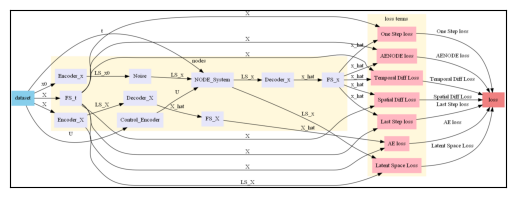

In [6]:
model.build_model()

In [7]:
problem = model.train_model(chkpnt_path, RS_train, ft_train, RS_val, ft_val, RS_test, ft_test, t[:, np.newaxis])

None
Number of parameters: 605195

 Current Learning Rate - 0.01
epoch: 0	train_loss: 11.53783	val_loss: 8.86106	eltime:  2.29327
epoch: 1	train_loss: 2.76680	val_loss: 2.44394	eltime:  3.73134
epoch: 2	train_loss: 1.44710	val_loss: 1.67339	eltime:  5.17986
epoch: 3	train_loss: 1.55401	val_loss: 1.69949	eltime:  6.61854
epoch: 4	train_loss: 1.22871	val_loss: 1.86299	eltime:  8.30183
Interrupted training loop.
